In [ ]:
from google.colab import drive
import os

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

print("Drive ready")

Mounted at /content/drive
Drive ready


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/seal_tracking_colab"

DATA_DIR = f"{PROJECT_DIR}/data"
VIDEO_DIR = f"{DATA_DIR}/raw_videos"
FRAME_DIR = f"{DATA_DIR}/frames"

OUTPUT_DIR = f"{PROJECT_DIR}/outputs"
FIGURE_DIR = f"{OUTPUT_DIR}/figures"
VIDEO_OUTPUT_DIR = f"{OUTPUT_DIR}/videos"

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
model = model.to(device)
model.eval()

print("Model loaded on:", device)

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 182MB/s]


Model loaded on: cuda


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import torch
import torchvision.transforms as transforms

In [ ]:
video_path = Path(VIDEO_DIR) / "seal_03.mp4"
dense_frames_dir = Path(FRAME_DIR) / "video_03_dense"
dense_frames_dir.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(video_path)

frame_interval = 3
frame_idx = 0
saved_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    if frame_idx % frame_interval == 0:
        frame_path = dense_frames_dir / f"frame_{frame_idx:04d}.jpg"
        cv2.imwrite(str(frame_path), frame)
        saved_count += 1

    frame_idx += 1

cap.release()

print(f"Saved {saved_count} dense frames")

Saved 83 dense frames


/content/drive/MyDrive/seal_tracking_colab/data/frames/video_03_dense/frame_0000.jpg


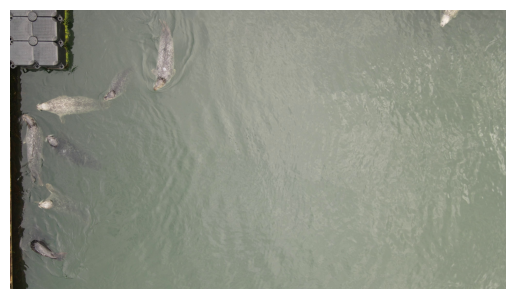

In [ ]:
frame_paths = sorted(dense_frames_dir.glob("*.jpg"))

image_path = frame_paths[0]
print(image_path)

image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
transform_518 = transforms.Compose([
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
def extract_dino_patch_features(image_path, model, transform, device):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model.forward_features(image_tensor)

    patch_tokens = features["x_norm_patchtokens"]
    batch_size, num_patches, feature_dim = patch_tokens.shape
    grid_size = int(num_patches ** 0.5)

    patch_grid = patch_tokens.reshape(batch_size, grid_size, grid_size, feature_dim)
    patch_features = patch_grid[0].cpu().numpy()

    return image, patch_features, grid_size

In [ ]:
def compute_similarity_map(patch_features, reference_feature):
    reference_feature = reference_feature / np.linalg.norm(reference_feature)

    patch_norms = np.linalg.norm(patch_features, axis=-1, keepdims=True)
    normalized_patches = patch_features / (patch_norms + 1e-8)

    similarity_map = np.sum(normalized_patches * reference_feature, axis=-1)

    return similarity_map

In [ ]:
def patch_bbox_to_image_bbox(bbox, grid_size, image_size=518):
    x_min, y_min, x_max, y_max = bbox
    patch_size = image_size / grid_size

    x_min_img = int(x_min * patch_size)
    x_max_img = int((x_max + 1) * patch_size)
    y_min_img = int(y_min * patch_size)
    y_max_img = int((y_max + 1) * patch_size)

    return x_min_img, y_min_img, x_max_img, y_max_img

In [ ]:
def get_bbox_center(bbox):
    x_min, y_min, x_max, y_max = bbox
    return ((x_min + x_max) / 2, (y_min + y_max) / 2)

In [ ]:
reference_frame_path = frame_paths[0]

image_ref, patch_features_ref, grid_size_ref = extract_dino_patch_features(
    reference_frame_path,
    model,
    transform_518,
    device
)

print("Grid size:", grid_size_ref)
print("Patch features:", patch_features_ref.shape)

Grid size: 37
Patch features: (37, 37, 384)


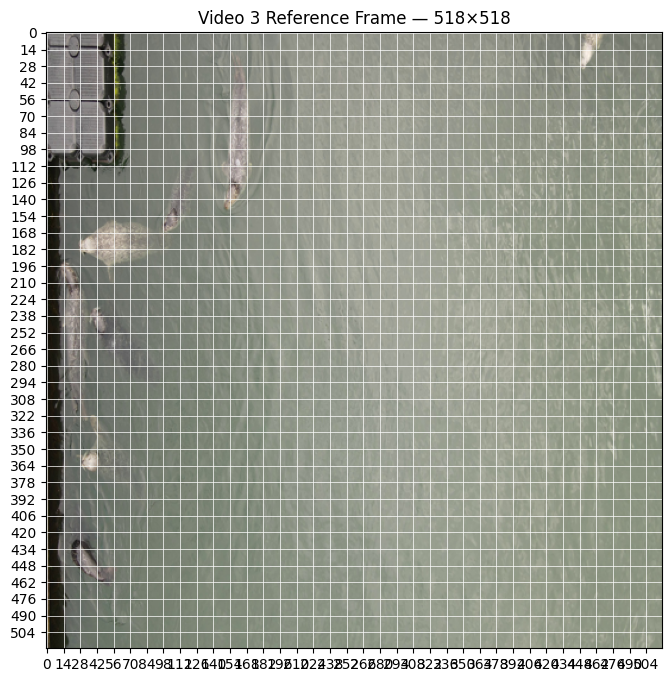

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(image_ref.resize((518, 518)))

plt.xticks(range(0, 518, int(518 / grid_size_ref)))
plt.yticks(range(0, 518, int(518 / grid_size_ref)))
plt.grid(color="white", linewidth=0.5)

plt.title("Video 3 Reference Frame — 518×518")
plt.show()

In [ ]:
image_points_multi = [
    (161,60), (162,77),(161,91),(162,112),(156,126),
    (56,168),(42,182),(60,184),(24,210),(26,224),
    (22,252),(25,434),(28,441),(35,448),(452,4),(454,14)
]

seal_points_multi = []

for x, y in image_points_multi:
    x_patch = int(x / 14)
    y_patch = int(y / 14)
    seal_points_multi.append((y_patch, x_patch))

print(seal_points_multi)

[(4, 11), (5, 11), (6, 11), (8, 11), (9, 11), (12, 4), (13, 3), (13, 4), (15, 1), (16, 1), (18, 1), (31, 1), (31, 2), (32, 2), (0, 32), (1, 32)]


In [ ]:
reference_features_multi = []

for y, x in seal_points_multi:
    reference_features_multi.append(patch_features_ref[y, x])

reference_feature_multi = np.mean(reference_features_multi, axis=0)

print(reference_feature_multi.shape)

(384,)


In [ ]:
def get_multi_bboxes_from_similarity(similarity_map, top_percent=5, min_area=3):
    cutoff = np.percentile(similarity_map, 100 - top_percent)
    binary_mask = similarity_map >= cutoff

    num_labels, labels = cv2.connectedComponents(binary_mask.astype(np.uint8))

    detections = []

    for label_id in range(1, num_labels):
        component_mask = labels == label_id
        area = component_mask.sum()

        if area < min_area:
            continue

        ys, xs = np.where(component_mask)

        x_min = xs.min()
        x_max = xs.max()
        y_min = ys.min()
        y_max = ys.max()

        bbox = (x_min, y_min, x_max, y_max)
        center = get_bbox_center(bbox)
        score = similarity_map[component_mask].mean()

        detections.append({
            "bbox": bbox,
            "center": center,
            "score": score,
            "area": area
        })

    return detections, binary_mask

In [ ]:
similarity_map_ref = compute_similarity_map(
    patch_features_ref,
    reference_feature_multi
)

detections_ref, binary_mask_ref = get_multi_bboxes_from_similarity(
    similarity_map_ref,
    top_percent=5,
    min_area=3
)

print("Detections:", len(detections_ref))
for det in detections_ref:
    print(det)

Detections: 5
{'bbox': (np.int64(10), np.int64(3), np.int64(12), np.int64(9)), 'center': (np.float64(11.0), np.float64(6.0)), 'score': np.float32(0.8481038), 'area': np.int64(14)}
{'bbox': (np.int64(3), np.int64(8), np.int64(8), np.int64(13)), 'center': (np.float64(5.5), np.float64(10.5)), 'score': np.float32(0.815152), 'area': np.int64(20)}
{'bbox': (np.int64(1), np.int64(14), np.int64(5), np.int64(20)), 'center': (np.float64(3.0), np.float64(17.0)), 'score': np.float32(0.80419075), 'area': np.int64(17)}
{'bbox': (np.int64(1), np.int64(21), np.int64(5), np.int64(27)), 'center': (np.float64(3.0), np.float64(24.0)), 'score': np.float32(0.7824419), 'area': np.int64(10)}
{'bbox': (np.int64(1), np.int64(31), np.int64(4), np.int64(32)), 'center': (np.float64(2.5), np.float64(31.5)), 'score': np.float32(0.81057096), 'area': np.int64(6)}


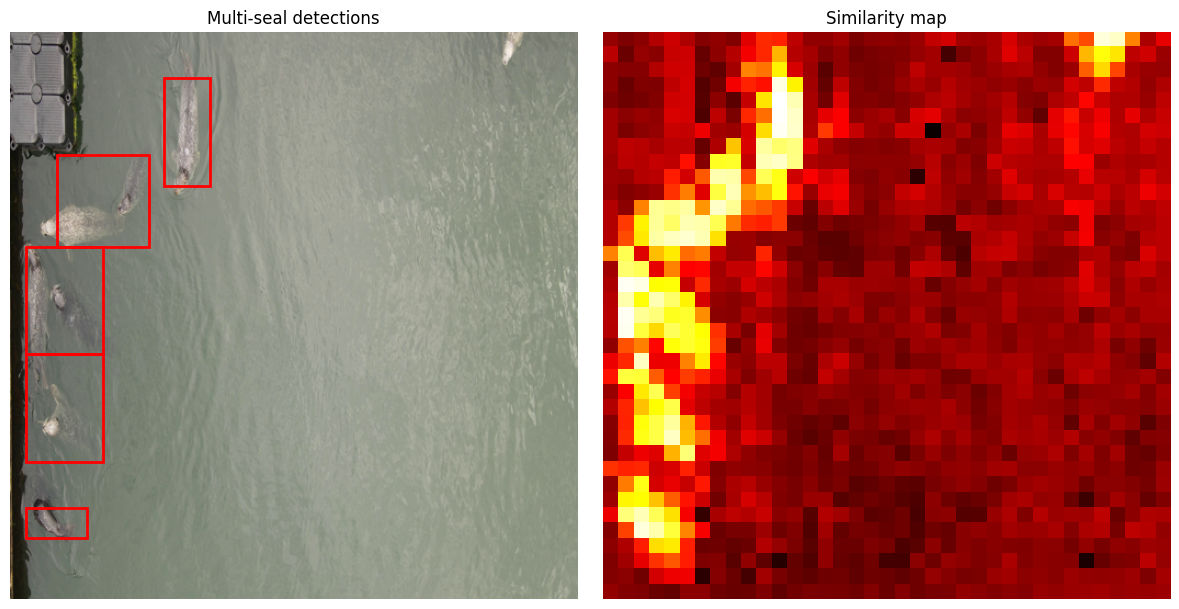

In [ ]:
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

image_display = image_ref.resize((518, 518))

axes[0].imshow(image_display)
axes[0].set_title("Multi-seal detections")
axes[0].axis("off")

for det in detections_ref:
    bbox = det["bbox"]

    x_min_img, y_min_img, x_max_img, y_max_img = patch_bbox_to_image_bbox(
        bbox,
        grid_size_ref,
        image_size=518
    )

    rect = patches.Rectangle(
        (x_min_img, y_min_img),
        x_max_img - x_min_img,
        y_max_img - y_min_img,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    axes[0].add_patch(rect)

axes[1].imshow(similarity_map_ref, cmap="hot")
axes[1].set_title("Similarity map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
multi_frame_results = []

top_percent = 5
min_area = 3

for frame_path in frame_paths:
    image, patch_features, grid_size = extract_dino_patch_features(
        frame_path,
        model,
        transform_518,
        device
    )

    similarity_map = compute_similarity_map(
        patch_features,
        reference_feature_multi
    )

    detections, binary_mask = get_multi_bboxes_from_similarity(
        similarity_map,
        top_percent=top_percent,
        min_area=min_area
    )

    multi_frame_results.append({
        "image_path": frame_path,
        "detections": detections,
        "grid_size": grid_size
    })

print("Processed frames:", len(multi_frame_results))

Processed frames: 83


In [ ]:
def distance_between_centers(c1, c2):
    return np.sqrt((c1[0] - c2[0])**2 + (c1[1] - c2[1])**2)

In [ ]:
next_track_id = 0
active_tracks = {}
tracked_results = []

max_distance = 10  # patch-grid distance

for frame_idx, result in enumerate(multi_frame_results):
    detections = result["detections"]

    frame_tracks = []

    if frame_idx == 0:
        for det in detections:
            det["track_id"] = next_track_id
            active_tracks[next_track_id] = det["center"]
            frame_tracks.append(det)
            next_track_id += 1

    else:
        used_track_ids = set()

        for det in detections:
            center = det["center"]

            best_track_id = None
            best_distance = float("inf")

            for track_id, prev_center in active_tracks.items():
                if track_id in used_track_ids:
                    continue

                dist = distance_between_centers(center, prev_center)

                if dist < best_distance:
                    best_distance = dist
                    best_track_id = track_id

            if best_track_id is not None and best_distance <= max_distance:
                det["track_id"] = best_track_id
                active_tracks[best_track_id] = center
                used_track_ids.add(best_track_id)
            else:
                det["track_id"] = next_track_id
                active_tracks[next_track_id] = center
                next_track_id += 1

            frame_tracks.append(det)

    tracked_results.append({
        "image_path": result["image_path"],
        "tracks": frame_tracks,
        "grid_size": result["grid_size"]
    })

print("Total track IDs created:", next_track_id)

Total track IDs created: 7


In [ ]:
for i, result in enumerate(tracked_results[:10]):
    ids = [det["track_id"] for det in result["tracks"]]
    print(i, result["image_path"].name, ids)

0 frame_0000.jpg [0, 1, 2, 3, 4]
1 frame_0003.jpg [5, 0, 1, 2, 3, 4]
2 frame_0006.jpg [5, 0, 1, 2, 3, 4, 6]
3 frame_0009.jpg [5, 0, 2, 3, 4]
4 frame_0012.jpg [5, 0, 2, 3, 4, 6]
5 frame_0015.jpg [0, 3, 4, 6]
6 frame_0018.jpg [5, 2, 0, 3, 4, 6]
7 frame_0021.jpg [5, 0, 3, 4, 6]
8 frame_0024.jpg [5, 0, 3, 4, 6]
9 frame_0027.jpg [5, 0, 3, 4, 6]


In [ ]:
import matplotlib.patches as patches

display_interval = 5
display_tracked = tracked_results[::display_interval]

fig, axes = plt.subplots(
    len(display_tracked),
    1,
    figsize=(8, 5 * len(display_tracked))
)

if len(display_tracked) == 1:
    axes = [axes]

for i, result in enumerate(display_tracked):
    image = Image.open(result["image_path"]).convert("RGB").resize((518, 518))
    axes[i].imshow(image)
    axes[i].set_title(result["image_path"].name)
    axes[i].axis("off")

    for det in result["tracks"]:
        bbox = det["bbox"]
        track_id = det["track_id"]

        x_min_img, y_min_img, x_max_img, y_max_img = patch_bbox_to_image_bbox(
            bbox,
            result["grid_size"],
            image_size=518
        )

        rect = patches.Rectangle(
            (x_min_img, y_min_img),
            x_max_img - x_min_img,
            y_max_img - y_min_img,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        axes[i].add_patch(rect)
        axes[i].text(
            x_min_img,
            y_min_img - 5,
            f"ID {track_id}",
            color="red",
            fontsize=10,
            weight="bold"
        )

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Nearest-center ID assignment produced stable IDs for clearly visible seals.

ID switches occurred when seals overlapped, moved close together, or became partially submerged.

This shows that detection works, but identity consistency remains challenging in crowded/occluded scenes.

In [ ]:
import cv2
import numpy as np
from PIL import Image

output_video = (
    Path(VIDEO_OUTPUT_DIR)
    / "video_03_multi_seal_tracking_518.mp4"
)

fps = 10
frame_size = (518, 518)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    str(output_video),
    fourcc,
    fps,
    frame_size
)

for frame_idx, result in enumerate(tracked_results):

    image = (
        Image.open(result["image_path"])
        .convert("RGB")
        .resize(frame_size)
    )

    frame = np.array(image)

    for det in result["tracks"]:

        bbox = det["bbox"]
        track_id = det["track_id"]

        x_min, y_min, x_max, y_max = patch_bbox_to_image_bbox(
            bbox,
            result["grid_size"],
            image_size=518
        )

        cv2.rectangle(
            frame,
            (x_min, y_min),
            (x_max, y_max),
            (255, 0, 0),
            2
        )

        cv2.putText(
            frame,
            f"ID {track_id}",
            (x_min, max(25, y_min - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

    cv2.putText(
        frame,
        f"Frame {frame_idx}",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    writer.write(frame)

writer.release()

print("Saved:")
print(output_video)

Saved:
/content/drive/MyDrive/seal_tracking_colab/outputs/videos/video_03_multi_seal_tracking_518.mp4


## Appearance-based matching

In [ ]:
def cosine_similarity(feature_a, feature_b):
    feature_a = feature_a / (np.linalg.norm(feature_a) + 1e-8)
    feature_b = feature_b / (np.linalg.norm(feature_b) + 1e-8)
    return np.dot(feature_a, feature_b)


def extract_bbox_feature(patch_features, bbox):
    x_min, y_min, x_max, y_max = bbox

    bbox_features = patch_features[y_min:y_max + 1, x_min:x_max + 1]
    bbox_features = bbox_features.reshape(-1, bbox_features.shape[-1])

    mean_feature = bbox_features.mean(axis=0)

    return mean_feature


def distance_between_centers(c1, c2):
    return np.sqrt((c1[0] - c2[0])**2 + (c1[1] - c2[1])**2)

In [ ]:
multi_frame_results_with_features = []

top_percent = 5
min_area = 3

for frame_path in frame_paths:

    image, patch_features, grid_size = extract_dino_patch_features(
        frame_path,
        model,
        transform_518,
        device
    )

    similarity_map = compute_similarity_map(
        patch_features,
        reference_feature_multi
    )

    detections, binary_mask = get_multi_bboxes_from_similarity(
        similarity_map,
        top_percent=top_percent,
        min_area=min_area
    )

    for det in detections:
        det["feature"] = extract_bbox_feature(
            patch_features,
            det["bbox"]
        )

    multi_frame_results_with_features.append({
        "image_path": frame_path,
        "detections": detections,
        "grid_size": grid_size
    })

print("Processed frames:", len(multi_frame_results_with_features))

Processed frames: 83


In [ ]:
next_track_id = 0
active_tracks = {}
tracked_results_appearance = []

max_distance = 10
distance_weight = 0.6
appearance_weight = 0.4

for frame_idx, result in enumerate(multi_frame_results_with_features):

    detections = result["detections"]
    frame_tracks = []

    if frame_idx == 0:
        for det in detections:
            det["track_id"] = next_track_id

            active_tracks[next_track_id] = {
                "center": det["center"],
                "feature": det["feature"]
            }

            frame_tracks.append(det)
            next_track_id += 1

    else:
        used_track_ids = set()

        for det in detections:
            center = det["center"]
            feature = det["feature"]

            best_track_id = None
            best_score = float("inf")

            for track_id, track_info in active_tracks.items():

                if track_id in used_track_ids:
                    continue

                prev_center = track_info["center"]
                prev_feature = track_info["feature"]

                distance = distance_between_centers(center, prev_center)

                if distance > max_distance:
                    continue

                appearance_sim = cosine_similarity(feature, prev_feature)

                normalized_distance = distance / max_distance
                appearance_cost = 1 - appearance_sim

                score = (
                    distance_weight * normalized_distance
                    + appearance_weight * appearance_cost
                )

                if score < best_score:
                    best_score = score
                    best_track_id = track_id

            if best_track_id is not None:
                det["track_id"] = best_track_id

                active_tracks[best_track_id] = {
                    "center": center,
                    "feature": feature
                }

                used_track_ids.add(best_track_id)

            else:
                det["track_id"] = next_track_id

                active_tracks[next_track_id] = {
                    "center": center,
                    "feature": feature
                }

                next_track_id += 1

            frame_tracks.append(det)

    tracked_results_appearance.append({
        "image_path": result["image_path"],
        "tracks": frame_tracks,
        "grid_size": result["grid_size"]
    })

print("Total track IDs created:", next_track_id)

Total track IDs created: 7


In [ ]:
for i, result in enumerate(tracked_results_appearance[:10]):
    ids = [det["track_id"] for det in result["tracks"]]
    print(i, result["image_path"].name, ids)

0 frame_0000.jpg [0, 1, 2, 3, 4]
1 frame_0003.jpg [5, 0, 1, 2, 3, 4]
2 frame_0006.jpg [5, 0, 1, 2, 3, 4, 6]
3 frame_0009.jpg [5, 0, 2, 3, 4]
4 frame_0012.jpg [5, 0, 2, 3, 4, 6]
5 frame_0015.jpg [0, 3, 4, 6]
6 frame_0018.jpg [5, 2, 0, 3, 4, 6]
7 frame_0021.jpg [5, 0, 3, 4, 6]
8 frame_0024.jpg [5, 0, 3, 4, 6]
9 frame_0027.jpg [5, 0, 3, 4, 6]


In [ ]:
import matplotlib.patches as patches

display_interval = 5
display_tracked = tracked_results_appearance[::display_interval]

fig, axes = plt.subplots(
    len(display_tracked),
    1,
    figsize=(8, 5 * len(display_tracked))
)

if len(display_tracked) == 1:
    axes = [axes]

for i, result in enumerate(display_tracked):
    image = Image.open(result["image_path"]).convert("RGB").resize((518, 518))
    axes[i].imshow(image)
    axes[i].set_title(result["image_path"].name)
    axes[i].axis("off")

    for det in result["tracks"]:
        bbox = det["bbox"]
        track_id = det["track_id"]

        x_min_img, y_min_img, x_max_img, y_max_img = patch_bbox_to_image_bbox(
            bbox,
            result["grid_size"],
            image_size=518
        )

        rect = patches.Rectangle(
            (x_min_img, y_min_img),
            x_max_img - x_min_img,
            y_max_img - y_min_img,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        axes[i].add_patch(rect)
        axes[i].text(
            x_min_img,
            y_min_img - 5,
            f"ID {track_id}",
            color="red",
            fontsize=10,
            weight="bold"
        )

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Multi-seal tracking was implemented using DINO similarity-based detection followed by nearest-center ID assignment. The method produced stable IDs for clearly separated seals, but ID consistency degraded during overlap, close interaction, and partial submersion. Adding DINO appearance similarity gave limited improvement because individual seals had highly similar visual features and detections sometimes merged into a single component.


## KMeans splitting

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
def split_large_detection_with_kmeans(det, similarity_map, max_area=20, n_clusters=2):
    bbox = det["bbox"]
    x_min, y_min, x_max, y_max = bbox

    width = x_max - x_min + 1
    height = y_max - y_min + 1
    area = det["area"]

    if area <= max_area:
        return [det]

    component_region = similarity_map[y_min:y_max + 1, x_min:x_max + 1]

    cutoff = np.percentile(component_region, 70)
    ys, xs = np.where(component_region >= cutoff)

    if len(xs) < n_clusters:
        return [det]

    points = np.column_stack([xs + x_min, ys + y_min])

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(points)

    split_detections = []

    for cluster_id in range(n_clusters):
        cluster_points = points[labels == cluster_id]

        if len(cluster_points) == 0:
            continue

        xs_cluster = cluster_points[:, 0]
        ys_cluster = cluster_points[:, 1]

        new_bbox = (
            xs_cluster.min(),
            ys_cluster.min(),
            xs_cluster.max(),
            ys_cluster.max()
        )

        new_center = get_bbox_center(new_bbox)

        split_detections.append({
            "bbox": new_bbox,
            "center": new_center,
            "score": det["score"],
            "area": len(cluster_points)
        })

    return split_detections

In [ ]:
multi_frame_results_kmeans = []

top_percent = 5
min_area = 3

for frame_path in frame_paths:
    image, patch_features, grid_size = extract_dino_patch_features(
        frame_path,
        model,
        transform_518,
        device
    )

    similarity_map = compute_similarity_map(
        patch_features,
        reference_feature_multi
    )

    detections, binary_mask = get_multi_bboxes_from_similarity(
        similarity_map,
        top_percent=top_percent,
        min_area=min_area
    )

    improved_detections = []

    for det in detections:

        split_result = split_large_detection_with_kmeans(
            det,
            similarity_map,
            max_area=20,
            n_clusters=2
        )

        improved_detections.extend(split_result)

    detections = improved_detections

    multi_frame_results_kmeans.append({
        "image_path": frame_path,
        "detections": detections,
        "grid_size": grid_size
    })

print("Processed frames:", len(multi_frame_results_kmeans))

Processed frames: 83


In [ ]:
next_track_id = 0
active_tracks = {}
tracked_results_kmeans = []

max_distance = 10  # patch-grid distance

for frame_idx, result in enumerate(multi_frame_results_kmeans):
    detections = result["detections"]

    frame_tracks = []

    if frame_idx == 0:
        for det in detections:
            det["track_id"] = next_track_id
            active_tracks[next_track_id] = det["center"]
            frame_tracks.append(det)
            next_track_id += 1

    else:
        used_track_ids = set()

        for det in detections:
            center = det["center"]

            best_track_id = None
            best_distance = float("inf")

            for track_id, prev_center in active_tracks.items():
                if track_id in used_track_ids:
                    continue

                dist = distance_between_centers(center, prev_center)

                if dist < best_distance:
                    best_distance = dist
                    best_track_id = track_id

            if best_track_id is not None and best_distance <= max_distance:
                det["track_id"] = best_track_id
                active_tracks[best_track_id] = center
                used_track_ids.add(best_track_id)
            else:
                det["track_id"] = next_track_id
                active_tracks[next_track_id] = center
                next_track_id += 1

            frame_tracks.append(det)

    tracked_results_kmeans.append({
        "image_path": result["image_path"],
        "tracks": frame_tracks,
        "grid_size": result["grid_size"]
    })

print("Total track IDs created:", next_track_id)

Total track IDs created: 8


In [ ]:
import matplotlib.patches as patches

display_interval = 5
display_tracked = tracked_results_kmeans[::display_interval]

fig, axes = plt.subplots(
    len(display_tracked),
    1,
    figsize=(8, 5 * len(display_tracked))
)

if len(display_tracked) == 1:
    axes = [axes]

for i, result in enumerate(display_tracked):
    image = Image.open(result["image_path"]).convert("RGB").resize((518, 518))
    axes[i].imshow(image)
    axes[i].set_title(result["image_path"].name)
    axes[i].axis("off")

    for det in result["tracks"]:
        bbox = det["bbox"]
        track_id = det["track_id"]

        x_min_img, y_min_img, x_max_img, y_max_img = patch_bbox_to_image_bbox(
            bbox,
            result["grid_size"],
            image_size=518
        )

        rect = patches.Rectangle(
            (x_min_img, y_min_img),
            x_max_img - x_min_img,
            y_max_img - y_min_img,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        axes[i].add_patch(rect)
        axes[i].text(
            x_min_img,
            y_min_img - 5,
            f"ID {track_id}",
            color="red",
            fontsize=10,
            weight="bold"
        )

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

KMeans splitting improved some merged detections, but introduced more ID switches. Therefore, nearest-center tracking was kept as the more stable baseline.